# FedClinic-Fair — Final Notebook

## Lower-Tail-Aware Personalized Federated Learning on MedMNIST

This notebook presents the complete implementation and evaluation of **FedClinic-Fair**, a federated learning project focused on personalized learning under non-IID client data.

The project studies whether personalization can improve performance for weaker clients without reducing overall performance. We compare established federated learning methods such as **FedAvg, FedProx, FedPer, and Ditto** with lightweight personalization baselines and our project extensions, **WarmFedPer** and **ProxHead**.

### Research Question

> Under statistically heterogeneous simulated medical clients, can lightweight personalization improve lower-tail client performance while maintaining strong average performance?

### Experimental Setup

* **Datasets:** PneumoniaMNIST, BreastMNIST, and BloodMNIST
* **Methods:** FedAvg, FedProx, FedPer, Head-FT, Ditto, WarmFedPer, and ProxHead
* **Evaluation:** mean, worst-client, and bottom-two macro-F1, accuracy, calibration, and client-performance variation
* **Additional analysis:** heterogeneity sensitivity, representation comparison, client-level diagnostics, confusion matrices, and efficiency analysis
* **Validation:** hyperparameters are selected using validation data, while separate fresh seeds are used for final evaluation

**Scope:** The clients are simulated non-IID data partitions rather than real hospitals. Therefore, the results are intended as an algorithmic federated learning study and do not make clinical, privacy, or demographic-fairness claims.


Data preparation
      ↓
Non-IID client simulation
      ↓
FedAvg baseline
      ↓
FedProx / FedPer / Ditto
      ↓
Warm-start FedPer
      ↓
ProxHead
      ↓
Evaluation
      ↓
Comparison table
      ↓
Final conclusion

## 1. Run instructions for team mates

1. In Colab choose **Runtime → Change runtime type → T4 GPU** if available.
2. Run all cells top to bottom.
3. Keep `RUN_PROFILE = "workshop"` for the final project.
4. Set `USE_GOOGLE_DRIVE = True` if you want feature caches/results to persist across Colab restarts.
5. Use `RUN_PROFILE = "smoke"` only to verify the pipeline quickly.

In [ ]:
!pip -q install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.8 MB/s eta 0:00:00


In [ ]:
from __future__ import annotations

import copy, hashlib, json, math, os, platform, random, shutil, time, warnings
from contextlib import nullcontext
from pathlib import Path
from typing import Dict, List, Mapping, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy, sklearn, torch, torch.nn as nn
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy, friedmanchisquare, spearmanr, wilcoxon
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, log_loss, roc_auc_score
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import transforms
from torchvision.models import ResNet18_Weights, resnet18

import medmnist
from medmnist import INFO

warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

In [ ]:
# @title
RUN_PROFILE = 'workshop'   # 'smoke' or 'workshop'
USE_GOOGLE_DRIVE = False
RESUME_COMPLETED_RUNS = True

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = Path('/content/drive/MyDrive/FedClinic_Fair_Final')
else:
    ROOT = Path('/content/FedClinic_Fair_Final')

CACHE_DIR = ROOT / 'feature_cache'
RESULTS_DIR = ROOT / 'results'
for p in [ROOT, CACHE_DIR, RESULTS_DIR]: p.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATASETS = ['pneumoniamnist'] if RUN_PROFILE == 'smoke' else ['pneumoniamnist','breastmnist','bloodmnist']

CONFIRMATION_SEEDS = {
    'pneumoniamnist': [92] if RUN_PROFILE == 'smoke' else [92,102,112,122,132,142,152,162,172,182],
    'breastmnist': [92] if RUN_PROFILE == 'smoke' else [92,112,132,152,172],
    'bloodmnist': [92] if RUN_PROFILE == 'smoke' else [92,112,132,152,172],
}
DEV_SEED=42; N_CLIENTS=5; PRIMARY_ALPHA=0.3
GLOBAL_ROUNDS = 3 if RUN_PROFILE=='smoke' else 20
PERSONAL_ROUNDS = 2 if RUN_PROFILE=='smoke' else 10
LOCAL_EPOCHS=1; IMAGE_SIZE=96; FEATURE_BATCH_SIZE=256; TRAIN_BATCH_SIZE=64
ADAPTER_DIM=128; DROPOUT=0.15; ADAPTER_LR=1e-3; BASE_HEAD_LR=1e-3; WEIGHT_DECAY=1e-4
BOTTOM_K=2; ECE_BINS=10
HETEROGENEITY_SEEDS = [202] if RUN_PROFILE=='smoke' else [202,212,222]
REPRESENTATION_SEEDS = [302] if RUN_PROFILE=='smoke' else [302,312,322]
MIN_TRAIN_SAMPLES={'pneumoniamnist':40,'breastmnist':25,'bloodmnist':80}
METHODS=['FedAvg','FedProx','FedPer','Head-FT','WarmFedPer','Ditto','ProxHead']
TUNING_GRID={
    'FedProx_mu':[0.001,0.01,0.1],
    'HeadFT_lr':[5e-4,1e-3,2e-3], 'HeadFT_epochs':[1,3,5],
    'Ditto_lambda':[0.01,0.1,1.0],
    'ProxHead_mu':[0.01,0.1,1.0], 'ProxHead_lr':[5e-4,1e-3,2e-3],
}
print('Device:', DEVICE, '| Profile:', RUN_PROFILE, '| Root:', ROOT)

Device: cpu | Profile: workshop | Root: /content/FedClinic_Fair_Final


In [ ]:
# @title
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False
    torch.use_deterministic_algorithms(True, warn_only=True)
set_seed(DEV_SEED)

environment_df=pd.DataFrame({'component':['Python','PyTorch','Torchvision','NumPy','pandas','SciPy','scikit-learn','MedMNIST','Device'],
'version':[platform.python_version(),torch.__version__,__import__('torchvision').__version__,np.__version__,pd.__version__,scipy.__version__,sklearn.__version__,medmnist.__version__,str(DEVICE)]})
display(environment_df)

,component,version
0,Python,3.12.13
1,PyTorch,2.11.0+cpu
2,Torchvision,0.26.0+cpu
3,NumPy,2.0.2
4,pandas,2.2.2
5,SciPy,1.16.3
6,scikit-learn,1.6.1
7,MedMNIST,3.0.2
8,Device,cpu


## 2. Loading the three official MedMNIST benchmark splits

In [ ]:
def load_bundle(name):
    info=INFO[name]; cls=getattr(medmnist, info['python_class']); splits={}
    for split in ['train','val','test']:
        ds=cls(split=split, download=True)
        splits[split]={'images':np.asarray(ds.imgs), 'labels':np.asarray(ds.labels).reshape(-1).astype(np.int64)}
    labels={int(k):str(v) for k,v in info['label'].items()}
    return {'name':name,'display_name':info['python_class'],'task':info['task'],'n_classes':len(labels),'label_mapping':labels,'splits':splits}

dataset_bundles={name:load_bundle(name) for name in DATASETS}
summary=[]
for name,b in dataset_bundles.items():
    summary.append({'dataset':b['display_name'],'task':b['task'],'classes':b['n_classes'],
                    'train':len(b['splits']['train']['labels']),'validation':len(b['splits']['val']['labels']),
                    'test':len(b['splits']['test']['labels']),'shape':str(b['splits']['train']['images'].shape[1:])})
dataset_summary_df=pd.DataFrame(summary); display(dataset_summary_df)

100%|██████████| 4.17M/4.17M [00:01<00:00, 2.12MB/s]
100%|██████████| 560k/560k [00:00<00:00, 1.04MB/s]
100%|██████████| 35.5M/35.5M [00:06<00:00, 5.12MB/s]


,dataset,task,classes,train,validation,test,shape
0,PneumoniaMNIST,binary-class,2,4708,524,624,"(28, 28)"
1,BreastMNIST,binary-class,2,546,78,156,"(28, 28)"
2,BloodMNIST,multi-class,8,11959,1712,3421,"(28, 28, 3)"


## 3. Quality audit and primary-dataset EDA

In [ ]:
def stable_hash(x): return hashlib.sha256(np.ascontiguousarray(x).tobytes()).hexdigest()
quality=[]; hash_rows=[]
for name,b in dataset_bundles.items():
    for split,d in b['splits'].items():
        X,y=d['images'],d['labels']; flat=X.reshape(len(X),-1).astype(float)
        quality.append({'dataset':name,'split':split,'samples':len(X),'shape':str(X.shape[1:]),'dtype':str(X.dtype),
                        'min':float(X.min()),'max':float(X.max()),'nonfinite':int((~np.isfinite(flat)).sum()),
                        'invalid_labels':int((~np.isin(y,np.arange(b['n_classes']))).sum()),'constant_images':int((flat.std(1)==0).sum())})
        for i,(img,label) in enumerate(zip(X,y)): hash_rows.append({'dataset':name,'split':split,'index':i,'label':int(label),'hash':stable_hash(img)})
quality_report_df=pd.DataFrame(quality); display(quality_report_df)
hash_df=pd.DataFrame(hash_rows)
duplicate_report_df=(hash_df.groupby(['dataset','hash']).agg(rows=('hash','size'),split_count=('split','nunique'),label_count=('label','nunique')).reset_index())
duplicate_report_df=duplicate_report_df[duplicate_report_df.rows>1].copy()
print('Exact duplicate groups:',len(duplicate_report_df)); display(duplicate_report_df.head(20))
for name,b in dataset_bundles.items():
    for d in b['splits'].values():
        assert np.isfinite(d['images']).all(); assert set(np.unique(d['labels'])).issubset(set(range(b['n_classes'])))
print('Essential integrity checks passed.')

,dataset,split,samples,shape,dtype,min,max,nonfinite,invalid_labels,constant_images
0,pneumoniamnist,train,4708,"(28, 28)",uint8,0.0,255.0,0,0,0
1,pneumoniamnist,val,524,"(28, 28)",uint8,0.0,255.0,0,0,0
2,pneumoniamnist,test,624,"(28, 28)",uint8,0.0,254.0,0,0,0
3,breastmnist,train,546,"(28, 28)",uint8,0.0,255.0,0,0,0
4,breastmnist,val,78,"(28, 28)",uint8,1.0,255.0,0,0,0
5,breastmnist,test,156,"(28, 28)",uint8,0.0,254.0,0,0,0
6,bloodmnist,train,11959,"(28, 28, 3)",uint8,0.0,255.0,0,0,0
7,bloodmnist,val,1712,"(28, 28, 3)",uint8,0.0,255.0,0,0,0
8,bloodmnist,test,3421,"(28, 28, 3)",uint8,0.0,255.0,0,0,0


Exact duplicate groups: 45


,dataset,hash,rows,split_count,label_count
91,bloodmnist,01768683829328baf9ae989653d23be70204b365a329f9...,2,1,1
317,bloodmnist,04c46b18e78dd05152cbdbd3a6216915b254fe8e3295e4...,2,2,1
2650,bloodmnist,28565e637a55816240af4991aff839f9598359f5d300d6...,2,1,1
3011,bloodmnist,2e1357eaa909eed4d6cfacf5f6c0b32e8836e4aca62a87...,2,2,2
4736,bloodmnist,483db15cb9fee3826301a3606d27ff052315fd26f4a031...,2,1,1
5236,bloodmnist,4f9c9fea816a7864d5fb9b94bfe8e81930b2678620002d...,2,2,1
7360,bloodmnist,6fb4cbad6ed42059a30600f33abb95c5fadc47e9a757b4...,2,1,1
7963,bloodmnist,78766dfaaf637086dc37416a9c43ae15cc4deb0f1a7703...,2,1,1
9216,bloodmnist,8bda18d5d9f48156678b9cc56c277cde74f473a35a3aae...,2,1,1
9472,bloodmnist,8f6512056cc578cb9afda760404cb35b42a16d0f80ac80...,2,1,1


Essential integrity checks passed.


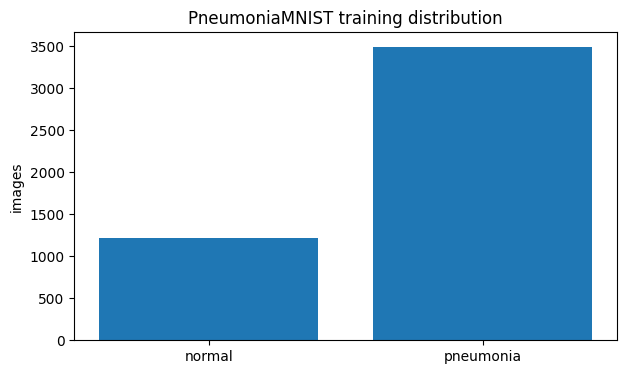

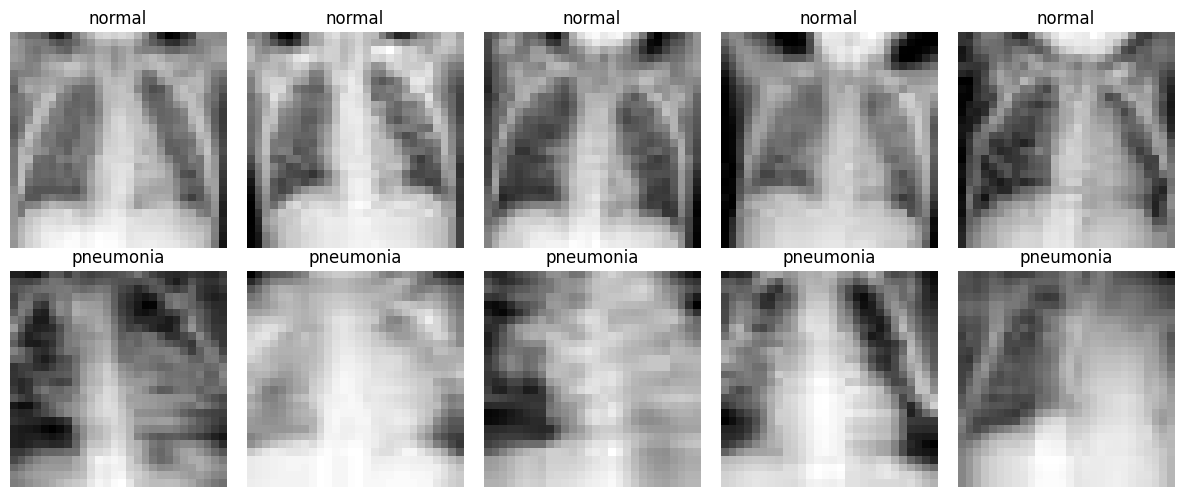

In [ ]:
MAIN_DATASET='pneumoniamnist'; main=dataset_bundles[MAIN_DATASET]
X=main['splits']['train']['images']; y=main['splits']['train']['labels']
counts=np.bincount(y,minlength=main['n_classes'])
plt.figure(figsize=(7,4)); plt.bar([main['label_mapping'][i] for i in range(main['n_classes'])],counts); plt.title('PneumoniaMNIST training distribution'); plt.ylabel('images'); plt.show()
rng=np.random.default_rng(DEV_SEED); fig,axes=plt.subplots(main['n_classes'],5,figsize=(12,5),squeeze=False)
for cls in range(main['n_classes']):
    ids=np.flatnonzero(y==cls); chosen=rng.choice(ids,size=min(5,len(ids)),replace=False)
    for j in range(5): axes[cls,j].axis('off')
    for j,i in enumerate(chosen): axes[cls,j].imshow(X[i],cmap='gray'); axes[cls,j].set_title(main['label_mapping'][cls])
fig.tight_layout(); plt.show()

In [ ]:
def gray01(img):
    a=np.asarray(img); a=a.mean(-1) if a.ndim==3 else a; return a.astype(np.float32)/255.0

def handcrafted(img):
    a=gray01(img); h,_=np.histogram(a.ravel(),bins=32,range=(0,1)); p=h/h.sum(); p=p[p>0]
    return {'pixel_mean':float(a.mean()),'pixel_std':float(a.std()),'pixel_median':float(np.median(a)),
            'image_entropy':float(entropy(p,base=2)),'edge_density':float((np.abs(np.diff(a,1,1)).mean()+np.abs(np.diff(a,1,0)).mean())/2),
            'horizontal_asymmetry':float(np.abs(a-np.fliplr(a)).mean())}
rows=[]
for split,d in main['splits'].items():
    for i,(img,label) in enumerate(zip(d['images'],d['labels'])): rows.append({'split':split,'index':i,'label':int(label),'class_name':main['label_mapping'][int(label)],**handcrafted(img)})
handcrafted_df=pd.DataFrame(rows)
cols=['pixel_mean','pixel_std','pixel_median','image_entropy','edge_density','horizontal_asymmetry']; out=[]
train_h=handcrafted_df[handcrafted_df.split=='train']
for c in cols:
    q1,q3=train_h[c].quantile([.25,.75]); iqr=q3-q1; lo=q1-1.5*iqr; hi=q3+1.5*iqr
    out.append({'feature':c,'lower':lo,'upper':hi,'flagged_rows':int(((train_h[c]<lo)|(train_h[c]>hi)).sum())})
outlier_report_df=pd.DataFrame(out); display(handcrafted_df.groupby('class_name')[cols].mean().round(4)); display(outlier_report_df)

,pixel_mean,pixel_std,pixel_median,image_entropy,edge_density,horizontal_asymmetry
class_name,,,,,,
normal,0.5498,0.1730,0.5703,4.3153,0.0545,0.0950
pneumonia,0.5786,0.1349,0.6013,3.8515,0.0345,0.0875


,feature,lower,upper,flagged_rows
0,pixel_mean,0.372068,0.778970,93
1,pixel_std,0.054953,0.232531,104
2,pixel_median,0.380392,0.819608,116
3,image_entropy,3.025670,4.973522,123
4,edge_density,0.000338,0.078660,0
5,horizontal_asymmetry,0.012950,0.162350,104


## 4. Frozen ResNet-18 feature banks
The FL methods train only a small adapter/classifier on frozen image features. A later sanity check compares ImageNet, random-convolution, and raw-pixel representations.

In [ ]:
IMAGENET_MEAN=(0.485,0.456,0.406); IMAGENET_STD=(0.229,0.224,0.225)
feature_transform=transforms.Compose([transforms.ToPILImage(),transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),transforms.ToTensor(),transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)])
class ImageArrayDataset(Dataset):
    def __init__(self,images): self.images=images
    def __len__(self): return len(self.images)
    def __getitem__(self,i):
        a=np.asarray(self.images[i]); a=np.repeat(a[...,None],3,-1) if a.ndim==2 else a
        return feature_transform(a)

def build_backbone(source):
    set_seed(2026); model=resnet18(weights=ResNet18_Weights.DEFAULT if source=='imagenet' else None); model.fc=nn.Identity()
    for p in model.parameters(): p.requires_grad=False
    return model.eval().to(DEVICE)

def extract_features(model,images):
    loader=DataLoader(ImageArrayDataset(images),batch_size=FEATURE_BATCH_SIZE,shuffle=False,num_workers=2,pin_memory=torch.cuda.is_available()); out=[]
    with torch.inference_mode():
        for batch in loader:
            batch=batch.to(DEVICE,non_blocking=True); ctx=torch.autocast('cuda',dtype=torch.float16) if DEVICE.type=='cuda' else nullcontext()
            with ctx: f=model(batch)
            out.append(f.float().cpu().numpy())
    return np.concatenate(out).astype(np.float32)

def load_feature_bank(dataset,source='imagenet'):
    path=CACHE_DIR/f'{dataset}_{source}_resnet18_{IMAGE_SIZE}.npz'
    if path.exists():
        z=np.load(path); print('Loaded',path.name); return {s:z[f'{s}_features'] for s in ['train','val','test']}
    model=build_backbone(source); bank={}
    for split,d in dataset_bundles[dataset]['splits'].items():
        print('Extracting',dataset,source,split); bank[split]=extract_features(model,d['images']); print(bank[split].shape)
    np.savez_compressed(path,**{f'{s}_features':v for s,v in bank.items()}); del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return bank

feature_banks={name:{'imagenet':load_feature_bank(name,'imagenet')} for name in DATASETS}

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 89.3MB/s]


Extracting pneumoniamnist imagenet train
(4708, 512)
Extracting pneumoniamnist imagenet val
(524, 512)
Extracting pneumoniamnist imagenet test
(624, 512)
Extracting breastmnist imagenet train
(546, 512)
Extracting breastmnist imagenet val
(78, 512)
Extracting breastmnist imagenet test
(156, 512)
Extracting bloodmnist imagenet train
(11959, 512)
Extracting bloodmnist imagenet val
(1712, 512)
Extracting bloodmnist imagenet test
(3421, 512)


## 5. Reproducible non-IID partitioning

In [ ]:
def sample_profiles(C,K,alpha,rng): return np.vstack([rng.dirichlet(np.full(K,alpha)) for _ in range(C)])
def allocate(labels,profiles,rng,min_per_class=0):
    C,K=profiles.shape; parts={k:[] for k in range(K)}
    for c in range(C):
        ids=np.flatnonzero(labels==c).copy(); rng.shuffle(ids); mandatory=K*min_per_class
        if len(ids)<mandatory: raise ValueError('not enough class samples')
        cur=0
        for k in range(K):
            if min_per_class: parts[k].extend(ids[cur:cur+min_per_class].astype(int).tolist()); cur+=min_per_class
        rem=ids[cur:]; counts=rng.multinomial(len(rem),profiles[c]); cur=0
        for k,n in enumerate(counts): parts[k].extend(rem[cur:cur+n].astype(int).tolist()); cur+=n
    for k in parts: rng.shuffle(parts[k])
    return parts

def validate(parts,n):
    ids=[i for v in parts.values() for i in v]; assert len(ids)==n and len(set(ids))==n and set(ids)==set(range(n))

def create_partitions(dataset,alpha,seed,max_attempts=10000):
    b=dataset_bundles[dataset]; C=b['n_classes']; min_eval=max(C,8)
    for attempt in range(1,max_attempts+1):
        profiles=sample_profiles(C,N_CLIENTS,alpha,np.random.default_rng(seed+attempt))
        tr=allocate(b['splits']['train']['labels'],profiles,np.random.default_rng(seed+10000+attempt),0)
        if min(map(len,tr.values()))<MIN_TRAIN_SAMPLES[dataset]: continue
        va=allocate(b['splits']['val']['labels'],profiles,np.random.default_rng(seed+20000+attempt),1)
        te=allocate(b['splits']['test']['labels'],profiles,np.random.default_rng(seed+30000+attempt),1)
        if min(map(len,va.values()))<min_eval or min(map(len,te.values()))<min_eval: continue
        for split,parts in [('train',tr),('val',va),('test',te)]: validate(parts,len(b['splits'][split]['labels']))
        return profiles,{'train':tr,'val':va,'test':te},attempt
    raise RuntimeError('Could not create partition')

def partition_diagnostics(dataset,parts,alpha,seed):
    b=dataset_bundles[dataset]; C=b['n_classes']; rows=[]
    for split,sp in parts.items():
        labels=b['splits'][split]['labels']; gc=np.bincount(labels,minlength=C).astype(float); gd=gc/gc.sum()
        for client,ids in sp.items():
            lc=np.bincount(labels[np.asarray(ids)],minlength=C).astype(int); ld=lc/max(lc.sum(),1)
            row={'dataset':dataset,'alpha':alpha,'seed':seed,'split':split,'client_id':client,'samples':len(ids),'majority_ratio':float(lc.max()/max(lc.sum(),1)),
                 'minority_support':int(lc.min()),'label_entropy':float(entropy(ld[ld>0],base=2)),'js_divergence_from_global':float(jensenshannon(ld,gd,base=2)**2)}
            for c in range(C): row[f'class_{c}_count']=int(lc[c])
            rows.append(row)
    return pd.DataFrame(rows)

_,example_parts,_=create_partitions(MAIN_DATASET,PRIMARY_ALPHA,DEV_SEED); display(partition_diagnostics(MAIN_DATASET,example_parts,PRIMARY_ALPHA,DEV_SEED).query("split=='train'"))

,dataset,alpha,seed,split,client_id,samples,majority_ratio,minority_support,label_entropy,js_divergence_from_global,class_0_count,class_1_count
0,pneumoniamnist,0.3,42,train,0,525,0.619048,200,0.958712,0.012629,200,325
1,pneumoniamnist,0.3,42,train,1,2908,0.806740,562,0.708241,0.004320,562,2346
2,pneumoniamnist,0.3,42,train,2,648,0.794753,133,0.732299,0.002810,133,515
3,pneumoniamnist,0.3,42,train,3,67,1.000000,0,0.000000,0.539741,67,0
4,pneumoniamnist,0.3,42,train,4,560,0.550000,252,0.992774,0.029392,252,308


## 6. Trainable adapter/head model and metrics

In [ ]:
class FeatureClassifier(nn.Module):
    def __init__(self,input_dim,n_classes):
        super().__init__(); self.adapter=nn.Sequential(nn.Linear(input_dim,ADAPTER_DIM),nn.LayerNorm(ADAPTER_DIM),nn.ReLU(),nn.Dropout(DROPOUT)); self.head=nn.Linear(ADAPTER_DIM,n_classes)
    def forward(self,x): return self.head(self.adapter(x))
def cpu_state(m): return {k:v.detach().cpu().clone() for k,v in m.state_dict().items()}
def subset(state,prefix): return {k:v.clone() for k,v in state.items() if k.startswith(prefix)}
def compose(template,shared,personal=None):
    r={k:v.clone() for k,v in template.items()}; r.update({k:v.clone() for k,v in shared.items()});
    if personal is not None: r.update({k:v.clone() for k,v in personal.items()})
    return r
def weighted_average(states,counts,keys):
    total=float(sum(counts)); out={}
    for k in keys:
        ts=[s[k] for s in states]
        out[k]=sum(t.float()*(n/total) for t,n in zip(ts,counts)).to(ts[0].dtype) if torch.is_floating_point(ts[0]) else ts[int(np.argmax(counts))].clone()
    return out

def feature_loader(features,labels,ids,shuffle,seed):
    ids=np.asarray(ids,dtype=int); ds=TensorDataset(torch.from_numpy(features[ids]).float(),torch.from_numpy(labels[ids]).long()); g=torch.Generator().manual_seed(seed)
    return DataLoader(ds,batch_size=TRAIN_BATCH_SIZE,shuffle=shuffle,generator=g if shuffle else None,num_workers=0)
def class_weights(labels,C):
    c=np.bincount(labels,minlength=C).astype(float); return torch.tensor(len(labels)/(C*np.maximum(c,1)),dtype=torch.float32)

In [ ]:
def ece_score(y,p,bins=10):
    conf=p.max(1); pred=p.argmax(1); ok=(pred==y).astype(float); edges=np.linspace(0,1,bins+1); e=0.
    for lo,hi in zip(edges[:-1],edges[1:]):
        m=(conf>=lo)&(conf<hi if hi<1 else conf<=hi)
        if m.any(): e+=m.mean()*abs(ok[m].mean()-conf[m].mean())
    return float(e)
def brier(y,p,C): return float(np.mean(np.sum((p-np.eye(C)[y])**2,axis=1)))
def metric_dict(y,p,C):
    pred=p.argmax(1); auc=np.nan
    try:
        if C==2 and len(np.unique(y))==2: auc=float(roc_auc_score(y,p[:,1]))
        elif C>2 and len(np.unique(y))==C: auc=float(roc_auc_score(y,p,multi_class='ovr',average='macro',labels=np.arange(C)))
    except ValueError: pass
    return {'accuracy':float(accuracy_score(y,pred)),'balanced_accuracy':float(balanced_accuracy_score(y,pred)),
            'macro_f1':float(f1_score(y,pred,labels=np.arange(C),average='macro',zero_division=0)),'auc':auc,
            'nll':float(log_loss(y,p,labels=np.arange(C))),'brier':brier(y,p,C),'ece':ece_score(y,p,ECE_BINS),'samples':len(y)}
def summarize_clients(df):
    r={}; high=['accuracy','balanced_accuracy','macro_f1','auc']; low=['nll','brier','ece']
    for m in high:
        v=df[m].to_numpy(float); s=df.samples.to_numpy(float); ok=np.isfinite(v); v,s=v[ok],s[ok]; k=min(BOTTOM_K,len(v))
        r[f'mean_{m}']=float(v.mean()); r[f'weighted_mean_{m}']=float(np.average(v,weights=s)); r[f'worst_{m}']=float(v.min()); r[f'bottom{k}_{m}']=float(np.sort(v)[:k].mean()); r[f'std_{m}']=float(v.std()); r[f'gap_{m}']=float(v.max()-v.min())
    for m in low:
        v=df[m].to_numpy(float); s=df.samples.to_numpy(float); ok=np.isfinite(v); v,s=v[ok],s[ok]; k=min(BOTTOM_K,len(v))
        r[f'mean_{m}']=float(v.mean()); r[f'weighted_mean_{m}']=float(np.average(v,weights=s)); r[f'worst_{m}']=float(v.max()); r[f'top{k}_{m}']=float(np.sort(v)[-k:].mean()); r[f'std_{m}']=float(v.std()); r[f'gap_{m}']=float(v.max()-v.min())
    return r
def selection_key(s): return (s['bottom2_macro_f1'],s['worst_macro_f1'],s['mean_macro_f1'])

def predict(model,loader):
    model=model.to(DEVICE).eval(); ys=[]; ps=[]
    with torch.inference_mode():
        for x,y in loader:
            prob=torch.softmax(model(x.to(DEVICE)),1); ys.extend(y.numpy().tolist()); ps.append(prob.cpu().numpy())
    return np.asarray(ys,int),np.concatenate(ps)
def eval_global(state,input_dim,C,features,labels,parts,seed):
    rows=[]
    for cid,ids in parts.items():
        m=FeatureClassifier(input_dim,C); m.load_state_dict(state); y,p=predict(m,feature_loader(features,labels,ids,False,seed+cid)); rows.append({'client_id':cid,**metric_dict(y,p,C)})
    df=pd.DataFrame(rows); return df,summarize_clients(df)
def eval_personal(states,input_dim,C,features,labels,parts,seed):
    rows=[]
    for cid,ids in parts.items():
        m=FeatureClassifier(input_dim,C); m.load_state_dict(states[cid]); y,p=predict(m,feature_loader(features,labels,ids,False,seed+cid)); rows.append({'client_id':cid,**metric_dict(y,p,C)})
    df=pd.DataFrame(rows); return df,summarize_clients(df)

## 7. Unified local optimizer

In [ ]:
def train_local(model,loader,weights,epochs=LOCAL_EPOCHS,adapter_lr=ADAPTER_LR,head_lr=BASE_HEAD_LR,freeze_adapter=False,prox_ref=None,prox_mu=0.,prox_prefixes=None):
    model=model.to(DEVICE).train()
    for p in model.adapter.parameters(): p.requires_grad=not freeze_adapter
    groups=[]
    if not freeze_adapter: groups.append({'params':model.adapter.parameters(),'lr':adapter_lr})
    groups.append({'params':model.head.parameters(),'lr':head_lr})
    opt=torch.optim.AdamW(groups,weight_decay=WEIGHT_DECAY); crit=nn.CrossEntropyLoss(weight=weights.to(DEVICE)); ref={k:v.to(DEVICE) for k,v in prox_ref.items()} if prox_ref is not None else None
    loss_sum=0.; n=0
    for _ in range(epochs):
        for x,y in loader:
            x,y=x.to(DEVICE),y.to(DEVICE); opt.zero_grad(set_to_none=True); ce=crit(model(x),y); prox=torch.tensor(0.,device=DEVICE)
            if ref is not None and prox_mu>0:
                for name,p in model.named_parameters():
                    use=prox_prefixes is None or any(name.startswith(q) for q in prox_prefixes)
                    if use and name in ref: prox=prox+(p-ref[name]).pow(2).mean()
            loss=ce+0.5*prox_mu*prox; loss.backward(); opt.step(); loss_sum+=float(loss.item())*len(y); n+=len(y)
    return loss_sum/max(n,1)

# Part II — Methods
## 8. FedAvg and FedProx

In [ ]:
def run_global_fl(dataset,bank,parts,seed,method='FedAvg',mu=0.,rounds=GLOBAL_ROUNDS,evaluate_test=True):
    t=time.time(); set_seed(seed); b=dataset_bundles[dataset]; C=b['n_classes']; D=bank['train'].shape[1]; labels=b['splits']['train']['labels']
    model=FeatureClassifier(D,C); server=cpu_state(model); keys=list(server); weights=class_weights(labels,C); best=copy.deepcopy(server); best_key=(-np.inf,)*3; best_val=None; best_round=0
    for rnd in range(1,rounds+1):
        states=[]; counts=[]
        for cid in range(N_CLIENTS):
            m=FeatureClassifier(D,C); m.load_state_dict(server); loader=feature_loader(bank['train'],labels,parts['train'][cid],True,seed+100*rnd+cid)
            train_local(m,loader,weights,prox_ref=server if method=='FedProx' else None,prox_mu=mu if method=='FedProx' else 0.); states.append(cpu_state(m)); counts.append(len(parts['train'][cid]))
        server=weighted_average(states,counts,keys); _,vs=eval_global(server,D,C,bank['val'],b['splits']['val']['labels'],parts['val'],seed+50000+rnd); k=selection_key(vs)
        if k>best_key: best_key=k; best=copy.deepcopy(server); best_val=vs.copy(); best_round=rnd
    result={'method':method,'best_state':best,'best_round':best_round,'validation_summary':best_val,'runtime_seconds':time.time()-t}
    if evaluate_test:
        tc,ts=eval_global(best,D,C,bank['test'],b['splits']['test']['labels'],parts['test'],seed+90000); result['test_clients']=tc; result['test_summary']=ts
    return result

## 9. FedPer-style personalization

In [ ]:
def run_fedper(dataset,bank,parts,seed,rounds=GLOBAL_ROUNDS):
    t=time.time(); set_seed(seed); b=dataset_bundles[dataset]; C=b['n_classes']; D=bank['train'].shape[1]; labels=b['splits']['train']['labels']; weights=class_weights(labels,C)
    base=cpu_state(FeatureClassifier(D,C)); shared=subset(base,'adapter.'); heads={c:copy.deepcopy(subset(base,'head.')) for c in range(N_CLIENTS)}; best_shared=copy.deepcopy(shared); best_heads=copy.deepcopy(heads); best_key=(-np.inf,)*3; best_val=None; best_round=0
    for rnd in range(1,rounds+1):
        states=[]; counts=[]
        for cid in range(N_CLIENTS):
            m=FeatureClassifier(D,C); m.load_state_dict(compose(base,shared,heads[cid])); loader=feature_loader(bank['train'],labels,parts['train'][cid],True,seed+100*rnd+cid); train_local(m,loader,weights); st=cpu_state(m); states.append(st); counts.append(len(parts['train'][cid])); heads[cid]=subset(st,'head.')
        shared=weighted_average(states,counts,list(shared)); pstate={c:compose(base,shared,heads[c]) for c in range(N_CLIENTS)}; _,vs=eval_personal(pstate,D,C,bank['val'],b['splits']['val']['labels'],parts['val'],seed+50000+rnd); k=selection_key(vs)
        if k>best_key: best_key=k; best_shared=copy.deepcopy(shared); best_heads=copy.deepcopy(heads); best_val=vs.copy(); best_round=rnd
    best={c:compose(base,best_shared,best_heads[c]) for c in range(N_CLIENTS)}; tc,ts=eval_personal(best,D,C,bank['test'],b['splits']['test']['labels'],parts['test'],seed+90000)
    return {'method':'FedPer','best_states':best,'best_round':best_round,'validation_summary':best_val,'test_clients':tc,'test_summary':ts,'runtime_seconds':time.time()-t}

## 10. Head-FT

In [ ]:
def run_headft(dataset,bank,parts,seed,fedavg_state,lr,epochs,evaluate_test=True):
    t=time.time(); b=dataset_bundles[dataset]; C=b['n_classes']; D=bank['train'].shape[1]; labels=b['splits']['train']['labels']; weights=class_weights(labels,C); states={}
    for cid in range(N_CLIENTS):
        m=FeatureClassifier(D,C); m.load_state_dict(fedavg_state); loader=feature_loader(bank['train'],labels,parts['train'][cid],True,seed+31000+cid); train_local(m,loader,weights,epochs=epochs,head_lr=lr,freeze_adapter=True); states[cid]=cpu_state(m)
    _,vs=eval_personal(states,D,C,bank['val'],b['splits']['val']['labels'],parts['val'],seed+32000); r={'method':'Head-FT','best_states':states,'validation_summary':vs,'runtime_seconds':time.time()-t}
    if evaluate_test: r['test_clients'],r['test_summary']=eval_personal(states,D,C,bank['test'],b['splits']['test']['labels'],parts['test'],seed+90000)
    return r

## 11. Ditto baseline

In [ ]:
def run_ditto(dataset,bank,parts,seed,lam,rounds=GLOBAL_ROUNDS,evaluate_test=True):
    t=time.time(); set_seed(seed); b=dataset_bundles[dataset]; C=b['n_classes']; D=bank['train'].shape[1]; labels=b['splits']['train']['labels']; weights=class_weights(labels,C)
    server=cpu_state(FeatureClassifier(D,C)); personal={c:copy.deepcopy(server) for c in range(N_CLIENTS)}; keys=list(server); best=copy.deepcopy(personal); best_server=copy.deepcopy(server); best_key=(-np.inf,)*3; best_val=None; best_round=0
    for rnd in range(1,rounds+1):
        gs=[]; counts=[]
        for cid in range(N_CLIENTS):
            m=FeatureClassifier(D,C); m.load_state_dict(server); loader=feature_loader(bank['train'],labels,parts['train'][cid],True,seed+100*rnd+cid); train_local(m,loader,weights); gs.append(cpu_state(m)); counts.append(len(parts['train'][cid]))
        server=weighted_average(gs,counts,keys)
        for cid in range(N_CLIENTS):
            m=FeatureClassifier(D,C); m.load_state_dict(personal[cid]); loader=feature_loader(bank['train'],labels,parts['train'][cid],True,seed+5000+100*rnd+cid); train_local(m,loader,weights,prox_ref=server,prox_mu=lam); personal[cid]=cpu_state(m)
        _,vs=eval_personal(personal,D,C,bank['val'],b['splits']['val']['labels'],parts['val'],seed+60000+rnd); k=selection_key(vs)
        if k>best_key: best_key=k; best=copy.deepcopy(personal); best_server=copy.deepcopy(server); best_val=vs.copy(); best_round=rnd
    result={'method':'Ditto','best_states':best,'best_server_state':best_server,'best_round':best_round,'validation_summary':best_val,'runtime_seconds':time.time()-t}
    if evaluate_test:
        tc,ts=eval_personal(best,D,C,bank['test'],b['splits']['test']['labels'],parts['test'],seed+90000); result['test_clients']=tc; result['test_summary']=ts
    return result

## 12. ProxHead — head-restricted proximal personalization

Starting from the selected FedAvg model, clients keep personalized heads while the adapter remains federated. The head is regularized toward the frozen FedAvg head:

$
L_i
=
L_{\mathrm{CE},i}
+
\frac{\mu}{2}
\left\lVert h_i-h_g \right\rVert_2^2
$

Position this as a **lightweight head-restricted proximal design**, not as a claim that proximal personalization itself is new.

In [ ]:
def run_proxhead(dataset,bank,parts,seed,fedavg_state,lr,mu,rounds=PERSONAL_ROUNDS,evaluate_test=True):
    t=time.time(); b=dataset_bundles[dataset]; C=b['n_classes']; D=bank['train'].shape[1]; labels=b['splits']['train']['labels']; weights=class_weights(labels,C)
    base=copy.deepcopy(fedavg_state); shared=subset(base,'adapter.'); global_head=subset(base,'head.'); heads={c:copy.deepcopy(global_head) for c in range(N_CLIENTS)}; best_shared=copy.deepcopy(shared); best_heads=copy.deepcopy(heads); best_key=(-np.inf,)*3; best_val=None; best_round=0
    for rnd in range(1,rounds+1):
        states=[]; counts=[]
        for cid in range(N_CLIENTS):
            m=FeatureClassifier(D,C); m.load_state_dict(compose(base,shared,heads[cid])); loader=feature_loader(bank['train'],labels,parts['train'][cid],True,seed+70000+100*rnd+cid); train_local(m,loader,weights,head_lr=lr,prox_ref=global_head,prox_mu=mu,prox_prefixes=['head.']); st=cpu_state(m); states.append(st); counts.append(len(parts['train'][cid])); heads[cid]=subset(st,'head.')
        shared=weighted_average(states,counts,list(shared)); pstate={c:compose(base,shared,heads[c]) for c in range(N_CLIENTS)}; _,vs=eval_personal(pstate,D,C,bank['val'],b['splits']['val']['labels'],parts['val'],seed+80000+rnd); k=selection_key(vs)
        if k>best_key: best_key=k; best_shared=copy.deepcopy(shared); best_heads=copy.deepcopy(heads); best_val=vs.copy(); best_round=rnd
    best={c:compose(base,best_shared,best_heads[c]) for c in range(N_CLIENTS)}; r={'method':'ProxHead','best_states':best,'best_round':best_round,'validation_summary':best_val,'runtime_seconds':time.time()-t}
    if evaluate_test: r['test_clients'],r['test_summary']=eval_personal(best,D,C,bank['test'],b['splits']['test']['labels'],parts['test'],seed+90000)
    return r

### WarmFedPer ablation

`WarmFedPer` is a controlled ablation of ProxHead. It uses the **same selected FedAvg checkpoint, the same personalized-head initialization, the same shared-adapter updates, the same personalization rounds, and the same head learning rate**, but sets the proximal strength to zero.

Therefore, the comparison `ProxHead` vs `WarmFedPer` isolates the contribution of the proximal head constraint rather than the effect of warm initialization or extra personalization rounds.

In [ ]:
def run_warmfedper(dataset, bank, parts, seed, fedavg_state, lr,
                   rounds=PERSONAL_ROUNDS, evaluate_test=True):
    """Compute-matched warm-start personalization ablation for ProxHead.

    This is intentionally the same training path as ProxHead with mu=0.
    No separate hyperparameter search is performed; it reuses the selected
    ProxHead head learning rate so that the only intended difference is
    the proximal regularization term.
    """
    result = run_proxhead(
        dataset=dataset,
        bank=bank,
        parts=parts,
        seed=seed,
        fedavg_state=fedavg_state,
        lr=lr,
        mu=0.0,
        rounds=rounds,
        evaluate_test=evaluate_test,
    )
    result['method'] = 'WarmFedPer'
    return result

# Part III — Validation-only development tuning
Each dataset uses seed 42 only for hyperparameter selection. Fresh confirmation seeds remain untouched.

In [ ]:
def tune_dataset(dataset):
    print('\nTUNING',dataset); bank=feature_banks[dataset]['imagenet']; _,parts,attempt=create_partitions(dataset,PRIMARY_ALPHA,DEV_SEED); rows=[]
    fedavg=run_global_fl(dataset,bank,parts,DEV_SEED,'FedAvg',evaluate_test=False)
    candidates=[]
    for mu in TUNING_GRID['FedProx_mu']:
        r=run_global_fl(dataset,bank,parts,DEV_SEED,'FedProx',mu,evaluate_test=False); candidates.append((mu,r)); rows.append({'dataset':dataset,'method':'FedProx','p1':'mu','v1':mu,**{f'val_{k}':v for k,v in r['validation_summary'].items()}})
    best_fedprox=max(candidates,key=lambda x:selection_key(x[1]['validation_summary']))[0]
    candidates=[]
    for lr in TUNING_GRID['HeadFT_lr']:
        for ep in TUNING_GRID['HeadFT_epochs']:
            r=run_headft(dataset,bank,parts,DEV_SEED,fedavg['best_state'],lr,ep,False); candidates.append((lr,ep,r)); rows.append({'dataset':dataset,'method':'Head-FT','p1':'lr','v1':lr,'p2':'epochs','v2':ep,**{f'val_{k}':v for k,v in r['validation_summary'].items()}})
    best_head=max(candidates,key=lambda x:selection_key(x[2]['validation_summary']))
    candidates=[]
    for lam in TUNING_GRID['Ditto_lambda']:
        r=run_ditto(dataset,bank,parts,DEV_SEED,lam,evaluate_test=False); candidates.append((lam,r)); rows.append({'dataset':dataset,'method':'Ditto','p1':'lambda','v1':lam,**{f'val_{k}':v for k,v in r['validation_summary'].items()}})
    best_ditto=max(candidates,key=lambda x:selection_key(x[1]['validation_summary']))[0]
    candidates=[]
    for mu in TUNING_GRID['ProxHead_mu']:
        for lr in TUNING_GRID['ProxHead_lr']:
            r=run_proxhead(dataset,bank,parts,DEV_SEED,fedavg['best_state'],lr,mu,evaluate_test=False); candidates.append((mu,lr,r)); rows.append({'dataset':dataset,'method':'ProxHead','p1':'mu','v1':mu,'p2':'lr','v2':lr,**{f'val_{k}':v for k,v in r['validation_summary'].items()}})
    best_prox=max(candidates,key=lambda x:selection_key(x[2]['validation_summary']))
    selected={'FedProx_mu':float(best_fedprox),'HeadFT_lr':float(best_head[0]),'HeadFT_epochs':int(best_head[1]),'Ditto_lambda':float(best_ditto),'ProxHead_mu':float(best_prox[0]),'ProxHead_lr':float(best_prox[1]),'partition_attempt':int(attempt)}
    print(json.dumps(selected,indent=2)); return selected,pd.DataFrame(rows)

In [ ]:
hp_path=RESULTS_DIR/'selected_hyperparameters.json'; tune_path=RESULTS_DIR/'validation_tuning_results.csv'
if RESUME_COMPLETED_RUNS and hp_path.exists() and tune_path.exists():
    selected_hyperparameters=json.load(open(hp_path)); tuning_results_df=pd.read_csv(tune_path); print('Loaded saved tuning')
else:
    selected_hyperparameters={}; frames=[]
    for dataset in DATASETS:
        selected,df=tune_dataset(dataset); selected_hyperparameters[dataset]=selected; frames.append(df)
    tuning_results_df=pd.concat(frames,ignore_index=True); json.dump(selected_hyperparameters,open(hp_path,'w'),indent=2); tuning_results_df.to_csv(tune_path,index=False)
display(pd.DataFrame(selected_hyperparameters).T)


TUNING pneumoniamnist
{
  "FedProx_mu": 0.01,
  "HeadFT_lr": 0.001,
  "HeadFT_epochs": 5,
  "Ditto_lambda": 1.0,
  "ProxHead_mu": 0.1,
  "ProxHead_lr": 0.002,
  "partition_attempt": 3
}

TUNING breastmnist
{
  "FedProx_mu": 0.001,
  "HeadFT_lr": 0.001,
  "HeadFT_epochs": 3,
  "Ditto_lambda": 1.0,
  "ProxHead_mu": 0.01,
  "ProxHead_lr": 0.0005,
  "partition_attempt": 10
}

TUNING bloodmnist
{
  "FedProx_mu": 0.01,
  "HeadFT_lr": 0.001,
  "HeadFT_epochs": 5,
  "Ditto_lambda": 0.1,
  "ProxHead_mu": 1.0,
  "ProxHead_lr": 0.0005,
  "partition_attempt": 1
}


,FedProx_mu,HeadFT_lr,HeadFT_epochs,Ditto_lambda,ProxHead_mu,ProxHead_lr,partition_attempt
pneumoniamnist,0.010,0.001,5.0,1.0,0.10,0.0020,3.0
breastmnist,0.001,0.001,3.0,1.0,0.01,0.0005,10.0
bloodmnist,0.010,0.001,5.0,0.1,1.00,0.0005,1.0


# Part IV — Fresh confirmation study
All methods use the same seed-specific partitions. The chosen hyperparameters are frozen.

In [ ]:
sum_path=RESULTS_DIR/'confirmation_summary.csv'; cli_path=RESULTS_DIR/'confirmation_clients.csv'; part_path=RESULTS_DIR/'confirmation_partitions.csv'
confirmation_summary_df=pd.read_csv(sum_path) if RESUME_COMPLETED_RUNS and sum_path.exists() else pd.DataFrame()
confirmation_clients_df=pd.read_csv(cli_path) if RESUME_COMPLETED_RUNS and cli_path.exists() else pd.DataFrame()
confirmation_partitions_df=pd.read_csv(part_path) if RESUME_COMPLETED_RUNS and part_path.exists() else pd.DataFrame()
def done(dataset,seed,method):
    return False if confirmation_summary_df.empty else bool(((confirmation_summary_df.dataset==dataset)&(confirmation_summary_df.seed==seed)&(confirmation_summary_df.method==method)).any())
def append_result(dataset,seed,r,pdf):
    global confirmation_summary_df,confirmation_clients_df,confirmation_partitions_df
    row={'dataset':dataset,'seed':seed,'method':r['method'],'runtime_seconds':float(r['runtime_seconds']),'best_round':r.get('best_round',np.nan),**r['test_summary']}
    c=r['test_clients'].copy(); c.insert(0,'method',r['method']); c.insert(0,'seed',seed); c.insert(0,'dataset',dataset)
    confirmation_summary_df=pd.concat([confirmation_summary_df,pd.DataFrame([row])],ignore_index=True); confirmation_clients_df=pd.concat([confirmation_clients_df,c],ignore_index=True)
    if confirmation_partitions_df.empty or not (((confirmation_partitions_df.dataset==dataset)&(confirmation_partitions_df.seed==seed)).any()): confirmation_partitions_df=pd.concat([confirmation_partitions_df,pdf],ignore_index=True)
    confirmation_summary_df.to_csv(sum_path,index=False); confirmation_clients_df.to_csv(cli_path,index=False); confirmation_partitions_df.to_csv(part_path,index=False)

In [ ]:
for dataset in DATASETS:
    bank=feature_banks[dataset]['imagenet']; hp=selected_hyperparameters[dataset]
    for seed in CONFIRMATION_SEEDS[dataset]:
        print('\n','='*70,'\nCONFIRMATION',dataset,seed); _,parts,_=create_partitions(dataset,PRIMARY_ALPHA,seed); pdf=partition_diagnostics(dataset,parts,PRIMARY_ALPHA,seed)
        # Recompute FedAvg state even on metric resume because downstream methods need its deterministic state.
        fedavg=run_global_fl(dataset,bank,parts,seed,'FedAvg')
        if not done(dataset,seed,'FedAvg'): append_result(dataset,seed,fedavg,pdf)
        if not done(dataset,seed,'FedProx'): append_result(dataset,seed,run_global_fl(dataset,bank,parts,seed,'FedProx',hp['FedProx_mu']),pdf)
        if not done(dataset,seed,'FedPer'): append_result(dataset,seed,run_fedper(dataset,bank,parts,seed),pdf)
        if not done(dataset,seed,'Head-FT'): append_result(dataset,seed,run_headft(dataset,bank,parts,seed,fedavg['best_state'],hp['HeadFT_lr'],hp['HeadFT_epochs']),pdf)
        if not done(dataset,seed,'WarmFedPer'): append_result(dataset,seed,run_warmfedper(dataset,bank,parts,seed,fedavg['best_state'],hp['ProxHead_lr']),pdf)
        if not done(dataset,seed,'Ditto'): append_result(dataset,seed,run_ditto(dataset,bank,parts,seed,hp['Ditto_lambda']),pdf)
        if not done(dataset,seed,'ProxHead'): append_result(dataset,seed,run_proxhead(dataset,bank,parts,seed,fedavg['best_state'],hp['ProxHead_lr'],hp['ProxHead_mu']),pdf)
print('Fresh confirmation completed.')


CONFIRMATION pneumoniamnist 92

CONFIRMATION pneumoniamnist 102

CONFIRMATION pneumoniamnist 112

CONFIRMATION pneumoniamnist 122

CONFIRMATION pneumoniamnist 132

CONFIRMATION pneumoniamnist 142

CONFIRMATION pneumoniamnist 152

CONFIRMATION pneumoniamnist 162

CONFIRMATION pneumoniamnist 172

CONFIRMATION pneumoniamnist 182

CONFIRMATION breastmnist 92

CONFIRMATION breastmnist 112

CONFIRMATION breastmnist 132

CONFIRMATION breastmnist 152

CONFIRMATION breastmnist 172

CONFIRMATION bloodmnist 92

CONFIRMATION bloodmnist 112

CONFIRMATION bloodmnist 132

CONFIRMATION bloodmnist 152

CONFIRMATION bloodmnist 172
Fresh confirmation completed.


## 13. Main confirmation results


 PNEUMONIAMNIST


mean_accuracy         worst_accuracy         bottom2_accuracy         mean_macro_f1         worst_macro_f1         bottom2_macro_f1         std_macro_f1          \
                    mean     std           mean     std             mean     std          mean     std           mean     std             mean     std         mean     std   
method                                                                                                                                                                        
Ditto             0.8962  0.0371         0.7914  0.0720           0.8295  0.0493        0.7016  0.0657         0.5047  0.0469           0.5523  0.0745       0.1386  0.0349   
FedAvg            0.7603  0.0597         0.5479  0.1482           0.5966  0.1456        0.6304  0.0924         0.4309  0.1261           0.4870  0.1221       0.1370  0.0368   
FedPer            0.8494  0.0530         0.6904  0.1148           0.7392  0.0965        0.6977  0.0813         0.5359  0.0995           0.5781  0.0989       0.1164  0.0410   
FedProx           0.7652  0.0674         0.5614  0.1592           0.6103  0.1613        0.6288  0.1056         0.4585  0.1585           0.4964  0.1563       0.1260  0.0458   
Head-FT           0.8432  0.0311         0.6654  0.0856           0.7284  0.0643        0.6940  0.0691         0.5071  0.0862           0.5550  0.0906       0.1343  0.0430   
ProxHead          0.8252  0.0429         0.6559  0.1145           0.7092  0.0833        0.6686  0.0960         0.5228  0.1087           0.5676  0.1023       0.0966  0.0371   
WarmFedPer        0.8495  0.0443         0.7058  0.0841           0.7556  0.0699        0.6981  0.0742         0.5385  0.1088           0.5874  0.0971       0.1086  0.0415   

           gap_macro_f1         mean_auc         worst_auc         mean_ece         worst_ece          
                   mean     std     mean     std      mean     std     mean     std      mean     std  
method                                                                                                 
Ditto            0.3541  0.0818   0.8974  0.0453    0.7773  0.1086   0.0781  0.0246    0.1486  0.0475  
FedAvg           0.3748  0.1022   0.9147  0.0328    0.8372  0.0570   0.1903  0.0603    0.3916  0.1444  
FedPer           0.3184  0.1116   0.9082  0.0501    0.8055  0.1333   0.0939  0.0253    0.1973  0.0747  
FedProx          0.3265  0.1097   0.9172  0.0333    0.8481  0.0546   0.1853  0.0706    0.3770  0.1626  
Head-FT          0.3553  0.1228   0.9159  0.0327    0.8418  0.0584   0.1151  0.0303    0.2700  0.0753  
ProxHead         0.2668  0.1030   0.9139  0.0325    0.8385  0.0543   0.1279  0.0302    0.2714  0.1008  
WarmFedPer       0.2988  0.1102   0.9018  0.0433    0.7937  0.1237   0.1059  0.0320    0.2248  0.0681


 BREASTMNIST


mean_accuracy         worst_accuracy         bottom2_accuracy         mean_macro_f1         worst_macro_f1         bottom2_macro_f1         std_macro_f1          \
                    mean     std           mean     std             mean     std          mean     std           mean     std             mean     std         mean     std   
method                                                                                                                                                                        
Ditto             0.8329  0.0455         0.5932  0.1931           0.6826  0.1213        0.5257  0.0665         0.4081  0.0930           0.4438  0.0490       0.0915  0.0402   
FedAvg            0.8064  0.0061         0.3997  0.1898           0.6358  0.0636        0.4854  0.1153         0.3023  0.1405           0.4023  0.1022       0.0966  0.0021   
FedPer            0.8650  0.0264         0.6874  0.0303           0.7720  0.0199        0.5351  0.0743         0.4423  0.0335           0.4689  0.0373       0.0757  0.0487   
FedProx           0.8064  0.0061         0.3997  0.1898           0.6358  0.0636        0.4854  0.1153         0.3023  0.1405           0.4023  0.1022       0.0966  0.0021   
Head-FT           0.8263  0.0124         0.5071  0.1473           0.6771  0.0555        0.5263  0.1102         0.4518  0.1061           0.4776  0.0837       0.0545  0.0272   
ProxHead          0.8145  0.0121         0.4084  0.2092           0.6428  0.0790        0.4939  0.1344         0.3225  0.1857           0.4228  0.1480       0.0879  0.0216   
WarmFedPer        0.8139  0.0107         0.4084  0.2092           0.6428  0.0790        0.4924  0.1310         0.3225  0.1857           0.4228  0.1480       0.0861  0.0255   

           gap_macro_f1         mean_auc         worst_auc         mean_ece         worst_ece          
                   mean     std     mean     std      mean     std     mean     std      mean     std  
method                                                                                                 
Ditto            0.2558  0.1046   0.8177  0.0814    0.5324  0.2459   0.1145  0.0327    0.2866  0.1588  
FedAvg           0.2541  0.0036   0.5989  0.1832    0.3800  0.2823   0.2247  0.0399    0.3920  0.0598  
FedPer           0.2128  0.1361   0.7550  0.0602    0.5261  0.0911   0.0978  0.0342    0.2076  0.0686  
FedProx          0.2541  0.0036   0.5989  0.1832    0.3800  0.2823   0.2247  0.0399    0.3920  0.0597  
Head-FT          0.1459  0.0688   0.6055  0.1829    0.3859  0.2815   0.1427  0.0118    0.2303  0.0389  
ProxHead         0.2339  0.0488   0.7024  0.1783    0.5080  0.2116   0.1450  0.0202    0.4411  0.1011  
WarmFedPer       0.2270  0.0643   0.7122  0.1777    0.5117  0.2115   0.1442  0.0198    0.4457  0.0966


 BLOODMNIST


mean_accuracy         worst_accuracy         bottom2_accuracy         mean_macro_f1         worst_macro_f1         bottom2_macro_f1         std_macro_f1          \
                    mean     std           mean     std             mean     std          mean     std           mean     std             mean     std         mean     std   
method                                                                                                                                                                        
Ditto             0.8922  0.0107         0.8582  0.0178           0.8612  0.0164        0.5041  0.0204         0.3827  0.0423           0.4260  0.0284       0.0832  0.0240   
FedAvg            0.7983  0.0231         0.6860  0.0986           0.7254  0.0469        0.5721  0.0232         0.4748  0.0566           0.5034  0.0332       0.0679  0.0120   
FedPer            0.8893  0.0091         0.8492  0.0256           0.8599  0.0176        0.5366  0.0604         0.4452  0.0881           0.4718  0.0758       0.0649  0.0171   
FedProx           0.7988  0.0268         0.6875  0.1251           0.7294  0.0611        0.5651  0.0296         0.4730  0.0596           0.5047  0.0380       0.0590  0.0232   
Head-FT           0.9051  0.0096         0.8674  0.0136           0.8752  0.0105        0.6703  0.0625         0.5659  0.0636           0.5833  0.0616       0.0798  0.0267   
ProxHead          0.8829  0.0126         0.8301  0.0339           0.8456  0.0216        0.6605  0.0481         0.5326  0.0446           0.5862  0.0365       0.0755  0.0197   
WarmFedPer        0.8802  0.0121         0.8281  0.0423           0.8403  0.0249        0.6570  0.0470         0.5530  0.0734           0.5845  0.0615       0.0702  0.0194   

           gap_macro_f1         mean_auc         worst_auc         mean_ece         worst_ece          
                   mean     std     mean     std      mean     std     mean     std      mean     std  
method                                                                                                 
Ditto            0.2307  0.0607   0.9482  0.0149    0.8950  0.0538   0.0494  0.0067    0.0717  0.0070  
FedAvg           0.1843  0.0336   0.9763  0.0070    0.9610  0.0191   0.0497  0.0062    0.0900  0.0237  
FedPer           0.1792  0.0498   0.9753  0.0126    0.9584  0.0259   0.0500  0.0319    0.0900  0.0749  
FedProx          0.1624  0.0662   0.9759  0.0071    0.9611  0.0198   0.0522  0.0086    0.1012  0.0495  
Head-FT          0.2176  0.0778   0.9826  0.0055    0.9675  0.0165   0.0268  0.0045    0.0396  0.0042  
ProxHead         0.2162  0.0548   0.9827  0.0051    0.9684  0.0157   0.0312  0.0048    0.0510  0.0132  
WarmFedPer       0.1964  0.0625   0.9824  0.0059    0.9697  0.0145   0.0321  0.0050    0.0551  0.0170

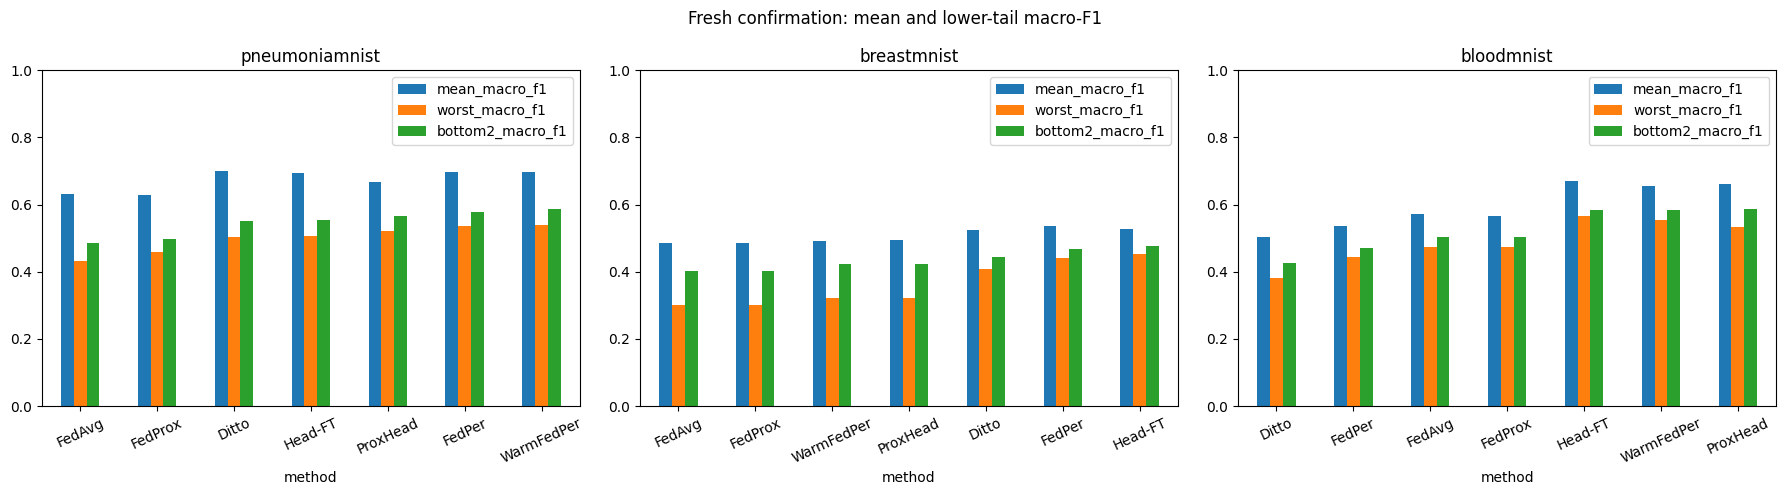

In [ ]:
metrics=['mean_accuracy','worst_accuracy','bottom2_accuracy','mean_macro_f1','worst_macro_f1','bottom2_macro_f1','std_macro_f1','gap_macro_f1','mean_auc','worst_auc','mean_ece','worst_ece']
for dataset in DATASETS:
    print('\n',dataset.upper()); d=confirmation_summary_df[confirmation_summary_df.dataset==dataset]; display(d.groupby('method')[metrics].agg(['mean','std']).round(4))
fig,axes=plt.subplots(1,len(DATASETS),figsize=(6*len(DATASETS),5),squeeze=False)
for ax,dataset in zip(axes[0],DATASETS):
    p=confirmation_summary_df[confirmation_summary_df.dataset==dataset].groupby('method')[['mean_macro_f1','worst_macro_f1','bottom2_macro_f1']].mean().sort_values('bottom2_macro_f1'); p.plot(kind='bar',ax=ax); ax.set_title(dataset); ax.set_ylim(0,1); ax.tick_params(axis='x',rotation=25)
fig.suptitle('Fresh confirmation: mean and lower-tail macro-F1'); fig.tight_layout(); plt.show()

# Part V — Statistics
Paired effects use the seed as the experimental unit.

In [ ]:
def bootstrap_ci(v,B=10000,seed=12345):
    v=np.asarray(v,float); rng=np.random.default_rng(seed); means=np.array([rng.choice(v,len(v),replace=True).mean() for _ in range(B)]); return float(np.quantile(means,.025)),float(np.quantile(means,.975))
rows=[]
for dataset in DATASETS:
    d=confirmation_summary_df[confirmation_summary_df.dataset==dataset]
    for metric in ['mean_macro_f1','worst_macro_f1','bottom2_macro_f1']:
        p=d.pivot(index='seed',columns='method',values=metric)
        for baseline in [m for m in METHODS if m!='ProxHead' and m in p.columns]:
            q=p[['ProxHead',baseline]].dropna(); diff=(q.ProxHead-q[baseline]).to_numpy();
            if not len(diff): continue
            stat,pv=(0.,1.) if np.allclose(diff,0) else wilcoxon(diff); lo,hi=bootstrap_ci(diff)
            rows.append({'dataset':dataset,'baseline':baseline,'metric':metric,'seed_pairs':len(diff),'mean_difference':float(diff.mean()),'median_difference':float(np.median(diff)),'seeds_improved_percent':float((diff>0).mean()*100),'ci95_lower':lo,'ci95_upper':hi,'wilcoxon_p':float(pv)})
paired_effects_df=pd.DataFrame(rows)
focus_baselines=['FedAvg','FedPer','WarmFedPer','Ditto']
display(
    paired_effects_df[
        paired_effects_df.baseline.isin(focus_baselines)
    ].sort_values(['dataset','metric','baseline']).round(4)
)

,dataset,baseline,metric,seed_pairs,mean_difference,median_difference,seeds_improved_percent,ci95_lower,ci95_upper,wilcoxon_p
53,bloodmnist,Ditto,bottom2_macro_f1,5,0.1602,0.1783,100.0,0.1300,0.1876,0.0625
48,bloodmnist,FedAvg,bottom2_macro_f1,5,0.0828,0.0855,100.0,0.0654,0.1010,0.0625
50,bloodmnist,FedPer,bottom2_macro_f1,5,0.1144,0.1170,100.0,0.0750,0.1539,0.0625
52,bloodmnist,WarmFedPer,bottom2_macro_f1,5,0.0017,0.0039,60.0,-0.0289,0.0325,1.0000
41,bloodmnist,Ditto,mean_macro_f1,5,0.1563,0.1604,100.0,0.1170,0.1957,0.0625
36,bloodmnist,FedAvg,mean_macro_f1,5,0.0884,0.1073,100.0,0.0572,0.1157,0.0625
38,bloodmnist,FedPer,mean_macro_f1,5,0.1239,0.1312,100.0,0.0837,0.1641,0.0625
40,bloodmnist,WarmFedPer,mean_macro_f1,5,0.0034,0.0104,60.0,-0.0191,0.0220,0.8125
47,bloodmnist,Ditto,worst_macro_f1,5,0.1499,0.1618,100.0,0.1188,0.1755,0.0625
42,bloodmnist,FedAvg,worst_macro_f1,5,0.0577,0.0318,100.0,0.0201,0.0964,0.0625


In [ ]:
def holm(ps):
    ps=np.asarray(ps,float); order=np.argsort(ps); out=np.empty_like(ps); running=0.; m=len(ps)
    for rank,i in enumerate(order): running=max(running,(m-rank)*ps[i]); out[i]=min(running,1.)
    return out
omnibus=[]; pair=[]
for dataset in DATASETS:
    d=confirmation_summary_df[confirmation_summary_df.dataset==dataset]
    for metric in ['bottom2_macro_f1','worst_macro_f1','mean_macro_f1']:
        p=d.pivot(index='seed',columns='method',values=metric); methods=[m for m in METHODS if m in p.columns]; comp=p[methods].dropna()
        if len(comp)>=3 and len(methods)>=3:
            st,pv=friedmanchisquare(*[comp[m].to_numpy() for m in methods]); omnibus.append({'dataset':dataset,'metric':metric,'seed_pairs':len(comp),'friedman_statistic':float(st),'friedman_p':float(pv)})
        local=[]
        for baseline in methods:
            if baseline=='ProxHead': continue
            q=p[['ProxHead',baseline]].dropna(); diff=(q.ProxHead-q[baseline]).to_numpy(); pv=1. if np.allclose(diff,0) else float(wilcoxon(diff).pvalue); local.append({'dataset':dataset,'metric':metric,'baseline':baseline,'raw_p':pv})
        if local:
            adj=holm([r['raw_p'] for r in local]);
            for r,a in zip(local,adj): r['holm_adjusted_p']=float(a); pair.append(r)
omnibus_df=pd.DataFrame(omnibus); holm_df=pd.DataFrame(pair); display(omnibus_df.round(4)); display(holm_df.round(4))

,dataset,metric,seed_pairs,friedman_statistic,friedman_p
0,pneumoniamnist,bottom2_macro_f1,10,19.4756,0.0034
1,pneumoniamnist,worst_macro_f1,10,20.3136,0.0024
2,pneumoniamnist,mean_macro_f1,10,18.1286,0.0059
3,breastmnist,bottom2_macro_f1,5,13.3418,0.0379
4,breastmnist,worst_macro_f1,5,13.3418,0.0379
5,breastmnist,mean_macro_f1,5,12.2259,0.0571
6,bloodmnist,bottom2_macro_f1,5,26.0571,0.0002
7,bloodmnist,worst_macro_f1,5,26.5714,0.0002
8,bloodmnist,mean_macro_f1,5,25.7143,0.0003


,dataset,metric,baseline,raw_p,holm_adjusted_p
0,pneumoniamnist,bottom2_macro_f1,FedAvg,0.0020,0.0117
1,pneumoniamnist,bottom2_macro_f1,FedProx,0.0098,0.0488
2,pneumoniamnist,bottom2_macro_f1,FedPer,1.0000,1.0000
3,pneumoniamnist,bottom2_macro_f1,Head-FT,0.6953,1.0000
4,pneumoniamnist,bottom2_macro_f1,WarmFedPer,0.2500,1.0000
5,pneumoniamnist,bottom2_macro_f1,Ditto,0.6250,1.0000
6,pneumoniamnist,worst_macro_f1,FedAvg,0.0039,0.0234
7,pneumoniamnist,worst_macro_f1,FedProx,0.0547,0.2734
8,pneumoniamnist,worst_macro_f1,FedPer,0.4609,1.0000
9,pneumoniamnist,worst_macro_f1,Head-FT,0.8438,1.0000


## 14. Cross-dataset ranking

In [ ]:
r=[]
for dataset in DATASETS:
    m=confirmation_summary_df[confirmation_summary_df.dataset==dataset].groupby('method').bottom2_macro_f1.mean().sort_values(ascending=False); ranks=m.rank(ascending=False)
    for method,val in m.items(): r.append({'dataset':dataset,'method':method,'bottom2_macro_f1':val,'rank':float(ranks[method])})
rank_df=pd.DataFrame(r); display(rank_df.round(4)); display(rank_df.groupby('method')['rank'].mean().sort_values().rename('average_rank').to_frame().round(3))

,dataset,method,bottom2_macro_f1,rank
0,pneumoniamnist,WarmFedPer,0.5874,1.0
1,pneumoniamnist,FedPer,0.5781,2.0
2,pneumoniamnist,ProxHead,0.5676,3.0
3,pneumoniamnist,Head-FT,0.5550,4.0
4,pneumoniamnist,Ditto,0.5523,5.0
5,pneumoniamnist,FedProx,0.4964,6.0
6,pneumoniamnist,FedAvg,0.4870,7.0
7,breastmnist,Head-FT,0.4776,1.0
8,breastmnist,FedPer,0.4689,2.0
9,breastmnist,Ditto,0.4438,3.0


,average_rank
method,
WarmFedPer,2.500
Head-FT,2.667
ProxHead,2.833
FedPer,3.333
Ditto,5.000
FedProx,5.500
FedAvg,6.167


# Part VI — Heterogeneity sensitivity on PneumoniaMNIST

mean_macro_f1  worst_macro_f1  bottom2_macro_f1
alpha method                                                     
0.1   FedAvg             0.4973          0.2865            0.2964
      FedPer             0.5815          0.4106            0.4849
      ProxHead           0.6044          0.4426            0.4799
      WarmFedPer         0.5973          0.4397            0.4712
0.3   FedAvg             0.6643          0.4508            0.5214
      FedPer             0.7192          0.5974            0.6256
      ProxHead           0.7180          0.5940            0.6106
      WarmFedPer         0.7246          0.5962            0.6265
1.0   FedAvg             0.7629          0.6148            0.6696
      FedPer             0.8120          0.7347            0.7556
      ProxHead           0.7945          0.7063            0.7255
      WarmFedPer         0.7969          0.7013            0.7264

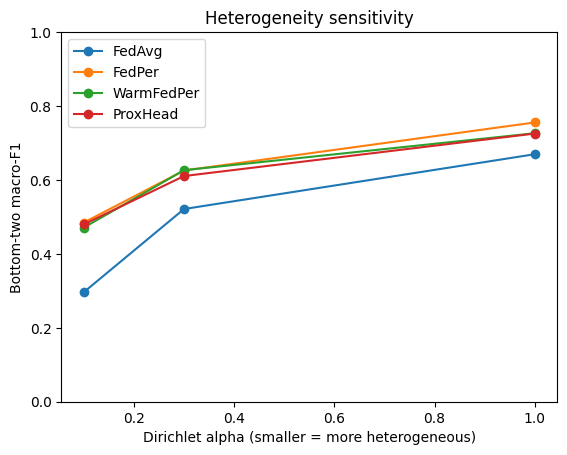

In [ ]:
het_path=RESULTS_DIR/'heterogeneity_results.csv'
required_het_methods=['FedAvg','FedPer','WarmFedPer','ProxHead']

if RESUME_COMPLETED_RUNS and het_path.exists():
    heterogeneity_results_df=pd.read_csv(het_path)
else:
    heterogeneity_results_df=pd.DataFrame()

bank=feature_banks[MAIN_DATASET]['imagenet']
hp=selected_hyperparameters[MAIN_DATASET]

for alpha in [0.1,0.3,1.0]:
    for seed in HETEROGENEITY_SEEDS:
        existing=set()
        if not heterogeneity_results_df.empty:
            q=heterogeneity_results_df[(heterogeneity_results_df.alpha==alpha)&(heterogeneity_results_df.seed==seed)]
            existing=set(q.method.astype(str))

        missing=[m for m in required_het_methods if m not in existing]
        if not missing:
            continue

        _,parts,_=create_partitions(MAIN_DATASET,alpha,seed)

        # FedAvg state is needed as the shared warm-start anchor for both
        # WarmFedPer and ProxHead. Recomputing it is deterministic for this seed.
        fa=run_global_fl(MAIN_DATASET,bank,parts,seed,'FedAvg')
        new_rows=[]

        if 'FedAvg' in missing:
            new_rows.append({'alpha':alpha,'seed':seed,'method':'FedAvg',**fa['test_summary']})

        if 'FedPer' in missing:
            fp=run_fedper(MAIN_DATASET,bank,parts,seed)
            new_rows.append({'alpha':alpha,'seed':seed,'method':'FedPer',**fp['test_summary']})

        if 'WarmFedPer' in missing:
            wf=run_warmfedper(
                MAIN_DATASET,bank,parts,seed,fa['best_state'],hp['ProxHead_lr']
            )
            new_rows.append({'alpha':alpha,'seed':seed,'method':'WarmFedPer',**wf['test_summary']})

        if 'ProxHead' in missing:
            ph=run_proxhead(
                MAIN_DATASET,bank,parts,seed,fa['best_state'],
                hp['ProxHead_lr'],hp['ProxHead_mu']
            )
            new_rows.append({'alpha':alpha,'seed':seed,'method':'ProxHead',**ph['test_summary']})

        heterogeneity_results_df=pd.concat(
            [heterogeneity_results_df,pd.DataFrame(new_rows)],ignore_index=True
        )
        heterogeneity_results_df.to_csv(het_path,index=False)

heterogeneity_results_df=heterogeneity_results_df.sort_values(['alpha','seed','method']).reset_index(drop=True)
display(
    heterogeneity_results_df.groupby(['alpha','method'])[
        ['mean_macro_f1','worst_macro_f1','bottom2_macro_f1']
    ].mean().round(4)
)

for method in required_het_methods:
    d=(heterogeneity_results_df[heterogeneity_results_df.method==method]
       .groupby('alpha').bottom2_macro_f1.mean().sort_index())
    plt.plot(d.index,d.values,marker='o',label=method)
plt.xlabel('Dirichlet alpha (smaller = more heterogeneous)')
plt.ylabel('Bottom-two macro-F1')
plt.ylim(0,1)
plt.legend()
plt.title('Heterogeneity sensitivity')
plt.show()

# Part VII — Representation sanity check
This directly tests the earlier surprising observation that random frozen features could be competitive with ImageNet features.

In [ ]:
def raw_bank(dataset):
    out={}
    for split,d in dataset_bundles[dataset]['splits'].items(): out[split]=(d['images'].astype(np.float32)/255.).reshape(len(d['images']),-1)
    return out
feature_banks[MAIN_DATASET]['random']=load_feature_bank(MAIN_DATASET,'random'); feature_banks[MAIN_DATASET]['raw']=raw_bank(MAIN_DATASET)
rep_path=RESULTS_DIR/'representation_ablation.csv'
if RESUME_COMPLETED_RUNS and rep_path.exists(): representation_results_df=pd.read_csv(rep_path)
else:
    rows=[]
    for source in ['imagenet','random','raw']:
        bank=feature_banks[MAIN_DATASET][source]
        for seed in REPRESENTATION_SEEDS:
            _,parts,_=create_partitions(MAIN_DATASET,PRIMARY_ALPHA,seed); x=run_global_fl(MAIN_DATASET,bank,parts,seed,'FedAvg'); rows.append({'feature_source':source,'seed':seed,**x['test_summary']})
        pd.DataFrame(rows).to_csv(rep_path,index=False)
    representation_results_df=pd.DataFrame(rows)
display(representation_results_df.groupby('feature_source')[['mean_macro_f1','worst_macro_f1','bottom2_macro_f1']].agg(['mean','std']).round(4))

Extracting pneumoniamnist random train
(4708, 512)
Extracting pneumoniamnist random val
(524, 512)
Extracting pneumoniamnist random test
(624, 512)


mean_macro_f1         worst_macro_f1         bottom2_macro_f1        
                        mean     std           mean     std             mean     std
feature_source                                                                      
imagenet              0.4246  0.2118         0.1113  0.1559           0.2236  0.1850
random                0.3289  0.0886         0.0382  0.0309           0.1512  0.1136
raw                   0.3309  0.0898         0.0382  0.0309           0.1562  0.1156

# Part VIII — Client-support diagnostics

,support_variable,method,spearman_rho,p_value,observations
0,train_samples,FedPer,-0.2335,0.1026,50
1,train_samples,ProxHead,-0.0795,0.5831,50
2,minority_support,FedPer,0.0852,0.5565,50
3,minority_support,ProxHead,0.0922,0.5241,50
4,majority_ratio,FedPer,-0.1995,0.1647,50
5,majority_ratio,ProxHead,-0.1874,0.1925,50
6,label_entropy,FedPer,0.1995,0.1647,50
7,label_entropy,ProxHead,0.1874,0.1925,50
8,js_divergence_from_global,FedPer,0.1542,0.2850,50
9,js_divergence_from_global,ProxHead,0.2764,0.0520,50


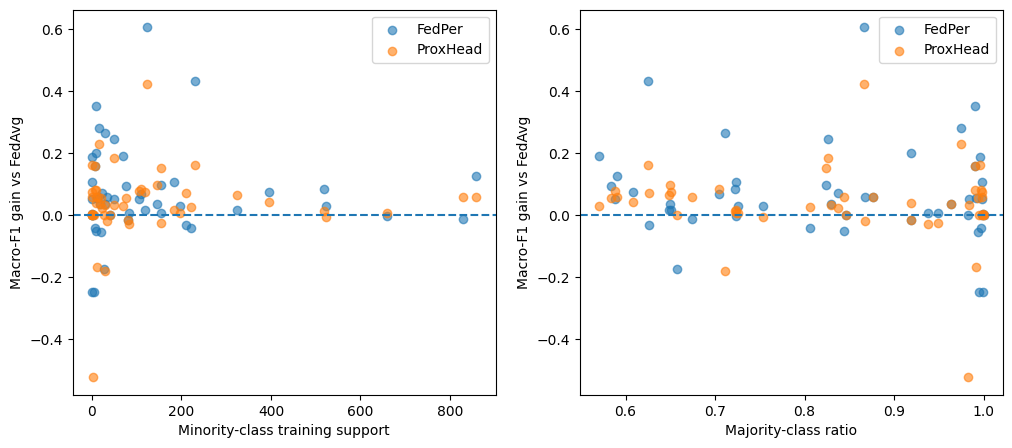

In [ ]:
mc=confirmation_clients_df[confirmation_clients_df.dataset==MAIN_DATASET]; ms=confirmation_partitions_df[(confirmation_partitions_df.dataset==MAIN_DATASET)&(confirmation_partitions_df.split=='train')][['seed','client_id','samples','majority_ratio','minority_support','label_entropy','js_divergence_from_global']].drop_duplicates().rename(columns={'samples':'train_samples'})
p=mc.pivot_table(index=['seed','client_id'],columns='method',values=['macro_f1','accuracy','balanced_accuracy','ece']).reset_index(); p.columns=['_'.join(str(q) for q in c if str(q) not in {'','None'}) if isinstance(c,tuple) else c for c in p.columns]; diag=p.merge(ms,on=['seed','client_id'],how='left')
for m in ['FedPer','ProxHead']: diag[f'delta_macro_f1_{m}']=diag[f'macro_f1_{m}']-diag['macro_f1_FedAvg']
rows=[]
for support in ['train_samples','minority_support','majority_ratio','label_entropy','js_divergence_from_global']:
    for m in ['FedPer','ProxHead']:
        out=f'delta_macro_f1_{m}'; q=diag[[support,out]].dropna(); rho,pv=spearmanr(q[support],q[out]); rows.append({'support_variable':support,'method':m,'spearman_rho':float(rho),'p_value':float(pv),'observations':len(q)})
client_diagnostic_df=diag; diagnostic_correlations_df=pd.DataFrame(rows); display(diagnostic_correlations_df.round(4))
fig,axes=plt.subplots(1,2,figsize=(12,5))
for m in ['FedPer','ProxHead']:
    axes[0].scatter(diag.minority_support,diag[f'delta_macro_f1_{m}'],alpha=.6,label=m); axes[1].scatter(diag.majority_ratio,diag[f'delta_macro_f1_{m}'],alpha=.6,label=m)
for ax in axes: ax.axhline(0,ls='--'); ax.legend()
axes[0].set_xlabel('Minority-class training support'); axes[0].set_ylabel('Macro-F1 gain vs FedAvg'); axes[1].set_xlabel('Majority-class ratio'); axes[1].set_ylabel('Macro-F1 gain vs FedAvg'); plt.show()

# Part IX — Prespecified weak-client confusion matrices

Diagnostic seed 92 | weakest FedAvg client 1


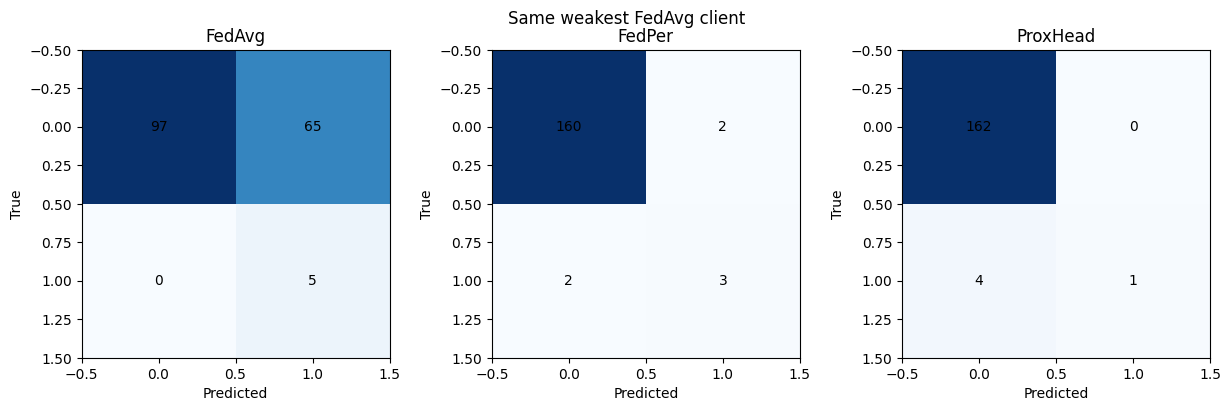

In [ ]:
DIAGNOSTIC_SEED=CONFIRMATION_SEEDS[MAIN_DATASET][0]; bank=feature_banks[MAIN_DATASET]['imagenet']; hp=selected_hyperparameters[MAIN_DATASET]; _,parts,_=create_partitions(MAIN_DATASET,PRIMARY_ALPHA,DIAGNOSTIC_SEED)
fa=run_global_fl(MAIN_DATASET,bank,parts,DIAGNOSTIC_SEED,'FedAvg'); fp=run_fedper(MAIN_DATASET,bank,parts,DIAGNOSTIC_SEED); ph=run_proxhead(MAIN_DATASET,bank,parts,DIAGNOSTIC_SEED,fa['best_state'],hp['ProxHead_lr'],hp['ProxHead_mu'])
weakest=int(fa['test_clients'].sort_values('macro_f1').iloc[0].client_id); print('Diagnostic seed',DIAGNOSTIC_SEED,'| weakest FedAvg client',weakest)
def state_pred(state):
    b=dataset_bundles[MAIN_DATASET]; D=bank['test'].shape[1]; m=FeatureClassifier(D,b['n_classes']); m.load_state_dict(state); return predict(m,feature_loader(bank['test'],b['splits']['test']['labels'],parts['test'][weakest],False,DIAGNOSTIC_SEED+95000))
preds={'FedAvg':state_pred(fa['best_state']),'FedPer':state_pred(fp['best_states'][weakest]),'ProxHead':state_pred(ph['best_states'][weakest])}
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,(method,(yt,prob)) in zip(axes,preds.items()):
    cm=confusion_matrix(yt,prob.argmax(1),labels=np.arange(main['n_classes'])); ax.imshow(cm,cmap='Blues'); ax.set_title(method); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]): ax.text(j,i,int(cm[i,j]),ha='center',va='center')
fig.suptitle('Same weakest FedAvg client'); plt.show()

## Reliability diagram on the same prespecified weak client

This is descriptive calibration analysis; lower ECE is better.

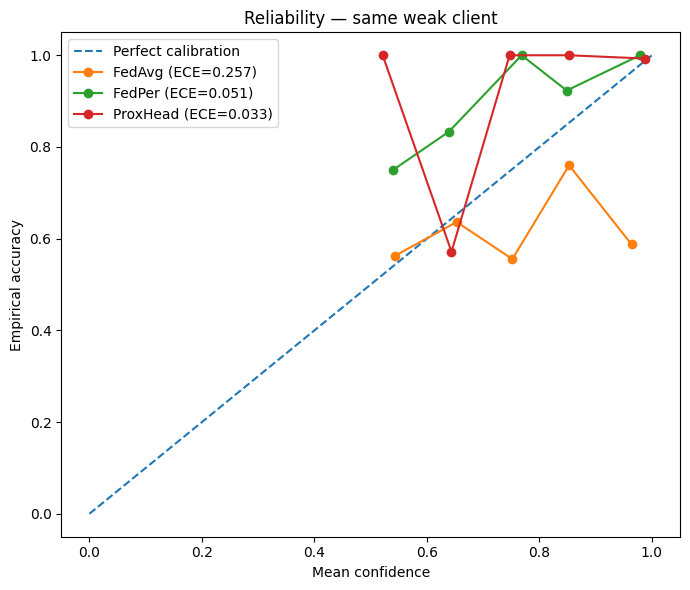

In [ ]:
def reliability_points(y,prob,bins=10):
    conf=prob.max(1); pred=prob.argmax(1); ok=(pred==y).astype(float); edges=np.linspace(0,1,bins+1); xs=[]; ys=[]
    for lo,hi in zip(edges[:-1],edges[1:]):
        m=(conf>=lo)&(conf<hi if hi<1 else conf<=hi)
        if m.any(): xs.append(float(conf[m].mean())); ys.append(float(ok[m].mean()))
    return np.asarray(xs),np.asarray(ys)
plt.figure(figsize=(7,6)); plt.plot([0,1],[0,1],ls='--',label='Perfect calibration')
for method,(yt,prob) in preds.items():
    x,ycal=reliability_points(yt,prob,ECE_BINS); plt.plot(x,ycal,marker='o',label=f"{method} (ECE={ece_score(yt,prob,ECE_BINS):.3f})")
plt.xlabel('Mean confidence'); plt.ylabel('Empirical accuracy'); plt.title('Reliability — same weak client'); plt.legend(); plt.tight_layout(); plt.show()

# Part X — Efficiency and communication

In [ ]:
m=FeatureClassifier(feature_banks[MAIN_DATASET]['imagenet']['train'].shape[1],main['n_classes']); adapter=sum(p.numel() for p in m.adapter.parameters()); head=sum(p.numel() for p in m.head.parameters()); total=adapter+head
def comm_mb(shared,rounds): return shared*4*N_CLIENTS*rounds*2/(1024**2)
efficiency_df=pd.DataFrame([
{'method':'FedAvg','shared_parameters':total,'personal_parameters_per_client':0,'approx_comm_MB':comm_mb(total,GLOBAL_ROUNDS)},
{'method':'FedProx','shared_parameters':total,'personal_parameters_per_client':0,'approx_comm_MB':comm_mb(total,GLOBAL_ROUNDS)},
{'method':'FedPer','shared_parameters':adapter,'personal_parameters_per_client':head,'approx_comm_MB':comm_mb(adapter,GLOBAL_ROUNDS)},
{'method':'Head-FT','shared_parameters':total,'personal_parameters_per_client':head,'approx_comm_MB':comm_mb(total,GLOBAL_ROUNDS)},
{'method':'WarmFedPer','shared_parameters':adapter,'personal_parameters_per_client':head,'approx_comm_MB':comm_mb(total,GLOBAL_ROUNDS)+comm_mb(adapter,PERSONAL_ROUNDS)},
{'method':'Ditto','shared_parameters':total,'personal_parameters_per_client':total,'approx_comm_MB':comm_mb(total,GLOBAL_ROUNDS)},
{'method':'ProxHead','shared_parameters':adapter,'personal_parameters_per_client':head,'approx_comm_MB':comm_mb(total,GLOBAL_ROUNDS)+comm_mb(adapter,PERSONAL_ROUNDS)}])
print('Adapter params:',adapter,'| Head params:',head,'| Head fraction:',round(100*head/total,3),'%'); display(efficiency_df.round(3))
runtime_summary_df=confirmation_summary_df.groupby(['dataset','method']).runtime_seconds.agg(['mean','std']).round(2); display(runtime_summary_df)

Adapter params: 65920 | Head params: 258 | Head fraction: 0.39 %


,method,shared_parameters,personal_parameters_per_client,approx_comm_MB
0,FedAvg,66178,0,50.490
1,FedProx,66178,0,50.490
2,FedPer,65920,258,50.293
3,Head-FT,66178,258,50.490
4,WarmFedPer,65920,258,75.636
5,Ditto,66178,66178,50.490
6,ProxHead,65920,258,75.636


mean   std
dataset        method                 
bloodmnist     Ditto       27.94  0.36
               FedAvg      13.01  0.12
               FedPer      13.27  0.17
               FedProx     16.72  0.38
               Head-FT      1.87  0.29
               ProxHead     7.20  0.51
               WarmFedPer   6.55  0.50
breastmnist    Ditto        2.83  0.41
               FedAvg       1.73  0.24
               FedPer       1.88  0.34
               FedProx      2.04  0.38
               Head-FT      0.11  0.02
               ProxHead     0.86  0.02
               WarmFedPer   0.89  0.16
pneumoniamnist Ditto       11.78  0.21
               FedAvg       5.61  0.47
               FedPer       5.65  0.43
               FedProx      7.06  0.54
               Head-FT      0.77  0.12
               ProxHead     3.13  0.44
               WarmFedPer   2.83  0.37

# Part XI — Automatic conservative conclusion

In [ ]:
# Simple final comparison of the main methods

final_comparison = (
    confirmation_summary_df
    .groupby(["dataset", "method"])[
        ["mean_macro_f1", "worst_macro_f1", "bottom2_macro_f1"]
    ]
    .mean()
    .reset_index()
)

display(final_comparison.round(4))

,dataset,method,mean_macro_f1,worst_macro_f1,bottom2_macro_f1
0,bloodmnist,Ditto,0.5041,0.3827,0.4260
1,bloodmnist,FedAvg,0.5721,0.4748,0.5034
2,bloodmnist,FedPer,0.5366,0.4452,0.4718
3,bloodmnist,FedProx,0.5651,0.4730,0.5047
4,bloodmnist,Head-FT,0.6703,0.5659,0.5833
5,bloodmnist,ProxHead,0.6605,0.5326,0.5862
6,bloodmnist,WarmFedPer,0.6570,0.5530,0.5845
7,breastmnist,Ditto,0.5257,0.4081,0.4438
8,breastmnist,FedAvg,0.4854,0.3023,0.4023
9,breastmnist,FedPer,0.5351,0.4423,0.4689


In [ ]:
# Comparing our selected method with the main FedAvg baseline

for dataset in DATASETS:
    results = final_comparison[final_comparison["dataset"] == dataset]

    fedavg = results[results["method"] == "FedAvg"]
    warm = results[results["method"] == "WarmFedPer"]

    if len(fedavg) > 0 and len(warm) > 0:
        fedavg_bottom2 = fedavg["bottom2_macro_f1"].iloc[0]
        warm_bottom2 = warm["bottom2_macro_f1"].iloc[0]

        print(dataset)
        print("FedAvg bottom-two Macro-F1:", round(fedavg_bottom2, 4))
        print("WarmFedPer bottom-two Macro-F1:", round(warm_bottom2, 4))
        print("Improvement:", round(warm_bottom2 - fedavg_bottom2, 4))
        print()

pneumoniamnist
FedAvg bottom-two Macro-F1: 0.487
WarmFedPer bottom-two Macro-F1: 0.5874
Improvement: 0.1005

breastmnist
FedAvg bottom-two Macro-F1: 0.4023
WarmFedPer bottom-two Macro-F1: 0.4228
Improvement: 0.0205

bloodmnist
FedAvg bottom-two Macro-F1: 0.5034
WarmFedPer bottom-two Macro-F1: 0.5845
Improvement: 0.0811



### Final Observation

The experiments show that personalized federated learning methods generally perform better than the FedAvg baseline on lower-performing clients.

WarmFedPer showed the strongest overall lower-tail performance across the three datasets, although the best method was not the same for every dataset. ProxHead also performed strongly, especially under higher client heterogeneity.

Therefore, WarmFedPer is selected as the overall best approach for this project based on its consistent bottom-two client performance.

# 15. Final positioning and limitations

#contribution
> Unconstrained personalized heads can improve average performance while harming lower-tail clients under simulated medical heterogeneity. We evaluate stronger controls and test whether a lightweight head-restricted proximal strategy can preserve personalization benefits while improving the weakest clients.

## What makes the final project stronger
- fresh confirmation seeds rather than repeated test tuning;
- two additional MedMNIST tasks, including an 8-class problem;
- FedProx and Ditto literature baselines;
- a compute-matched WarmFedPer ablation that isolates the proximal penalty;
- lower-tail and calibration metrics;
- paired statistics and bootstrap intervals;
- heterogeneity sensitivity;
- representation sanity check;
- mechanism-oriented client-support diagnostics;
- parameter/communication efficiency analysis;
- resumable exported artifacts.

## Limitations
- clients are simulated, not real hospitals;
- one mandatory evaluation example per class/client slightly constrains the pure Dirichlet split;
- frozen features are centrally precomputed in this simulation;
- no formal privacy/security mechanism is implemented;
- client-level parity is not demographic fairness;
- MedMNIST is not intended for clinical use.


#Development Observation

During the initial experiments, we compared FedAvg with FedPer to study whether client-specific classifier heads could improve performance under non-IID data. FedPer improved average performance, but in some experiments the weakest client's performance decreased.

This observation motivated the next stage of the project. We investigated whether personalization could be made more stable by starting from a trained FedAvg model and controlling how far the personalized classifier moves from the global solution. This led to the evaluation of WarmFedPer as a warm-start personalization ablation and ProxHead as a head-restricted proximal personalization extension.

The final experiments therefore focus not only on average accuracy, but also on worst-client and bottom-two client performance to better understand how personalization affects weaker clients.